In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
import gc

plt.style.use('seaborn-v0_8-whitegrid')

/opt/anaconda3/envs/docking/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


# Read the Reference & Trajectory Files

In [ ]:
def natural_sort(l):
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]
    return sorted(l, key = alphanum_key)

In [ ]:
systems = [
    {
        "name": "Apo",
        "pdb": "/Users/xuruixiang/Desktop/ape1_apo/system_eq/ape1_apo.h.pdb" ,
        "xtc": "/Users/xuruixiang/Desktop/ape1_apo/MD_result/apo_d*.xtc",
        "color": "#11b34a"
    },
    {
        "name": "PEG9 20%(w/w)",
        "pdb": "/Users/xuruixiang/Desktop/ape1_peg9_20p/system_eq/ape1_peg9_20p.h.pdb",
        "xtc": "/Users/xuruixiang/Desktop/ape1_peg9_20p/MD_result/peg9_20p_d*.xtc",
        "color": "#ff7f0e"
    },
    {
        "name": "PEG181 20%(w/w)",
        "pdb": "/Users/xuruixiang/Desktop/ape1_peg181_20p/system_eq/ape1_peg181_20p.h.pdb",
        "xtc": "/Users/xuruixiang/Desktop/ape1_peg181_20p/MD_result/peg181_20p_d*.xtc",
        "color": "#1f77b4"
    }
]

# Radius of Gyration Analysis

In [ ]:
def run_rg_analysis(system_list):
    results = {}
    for sys in system_list:
        xtc_files = natural_sort(glob.glob(sys['xtc']))
        u = mda.Universe(sys['pdb'], xtc_files)
        ca = u.select_atoms("protein and name CA")

        times = []
        rgs = []
        for ts in u.trajectory:
            times.append(u.trajectory.time / 1000.0) # ps -> ns
            rgs.append(ca.radius_of_gyration())

        results[sys['name']] = {
            "time": np.array(times),
            "rg": np.array(rgs),
            "color": sys['color']
        }
    return results

In [ ]:
def plot_rg_comparison(rg_data):
    plt.figure(figsize=(10, 5), dpi=120)
    for name, data in rg_data.items():
        plt.plot(data['time'], data['rg'], color=data['color'], alpha=0.15, lw=0.5)

        window = 50
        ma = np.convolve(data['rg'], np.ones(window)/window, mode='valid')
        plt.plot(data['time'][:len(ma)], ma, color=data['color'], lw=2, label=f"{name}")

    plt.title(r"Comparison of $C_\alpha$ Radius of Gyration ($R_g$)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Time (ns)", fontsize=12)
    plt.ylabel(r"$R_g$ ($\AA$)", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(frameon=True, loc='upper right')

    plt.tight_layout()
    plt.show()

In [ ]:
rg_data = run_rg_analysis(systems)
plot_rg_comparison(rg_data)

# RMSF Analysis

In [ ]:
def run_single_rmsf(sys):
    print(f"正在處理 {sys['name']} 的 RMSF 分析")

    xtc_files = natural_sort(glob.glob(sys['xtc']))
    u = mda.Universe(sys['pdb'], xtc_files)
    u0 = mda.Universe(sys['pdb'])
    ca = u.select_atoms("protein and name CA")

    # 1. 算出平均結構
    average = align.AverageStructure(u, u0, select='protein and name CA', in_memory=True).run()

    # 2. 對齊軌跡
    ref = average.results.universe
    aligner = align.AlignTraj(u, ref, select='protein and name CA', in_memory=True).run()

    # 3. 計算 RMSF
    rf = rms.RMSF(ca).run()

    result_data = {
        "resids": ca.resids.copy(),
        "rmsf": rf.results.rmsf.copy(),
        "color": sys['color']
    }

    del u, u0, average, aligner, rf
    gc.collect()

    return result_data

In [ ]:
def plot_rmsf_comparison(rmsf_results_dict):
    """
    接收包含多個系統結果的字典，畫在同一張圖上。
    """
    plt.figure(figsize=(12, 6), dpi=120)

    # --- Beta-core 區域定義 ---
    beta_cores = [
        (62, 68), (91, 95), (116, 120), (131, 135), (141, 144),
        (157, 161), (166, 171), (205, 210), (250, 251), (283, 287),
        (295, 300), (312, 316)
    ]

    first_label = True
    for start, end in beta_cores:
        plt.axvspan(start, end, color='yellow', alpha=0.15,
                    label=r"$\beta$-core regions" if first_label else "")
        first_label = False

    for name, data in rmsf_results_dict.items():
        plt.plot(data['resids'], data['rmsf'], color=data['color'], lw=2.0, label=name)

    plt.title("Root Mean Square Fluctuation (RMSF)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Residue Number", fontsize=12)
    plt.ylabel(r"RMSF ($\AA$)", fontsize=12)

    all_resids = [d['resids'] for d in rmsf_results_dict.values()]
    plt.xlim(np.min(all_resids), np.max(all_resids))

    max_rmsf = max([np.max(d['rmsf']) for d in rmsf_results_dict.values()])
    plt.ylim(0, max_rmsf * 1.25)

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc='upper right', frameon=True, fontsize=10, ncol=2)

    plt.tight_layout()
    plt.show()

正在處理 Apo 的 RMSF 分析 (包含軌跡對齊)...
正在處理 PEG9 20%(w/w) 的 RMSF 分析 (包含軌跡對齊)...
正在處理 PEG181 20%(w/w) 的 RMSF 分析 (包含軌跡對齊)...


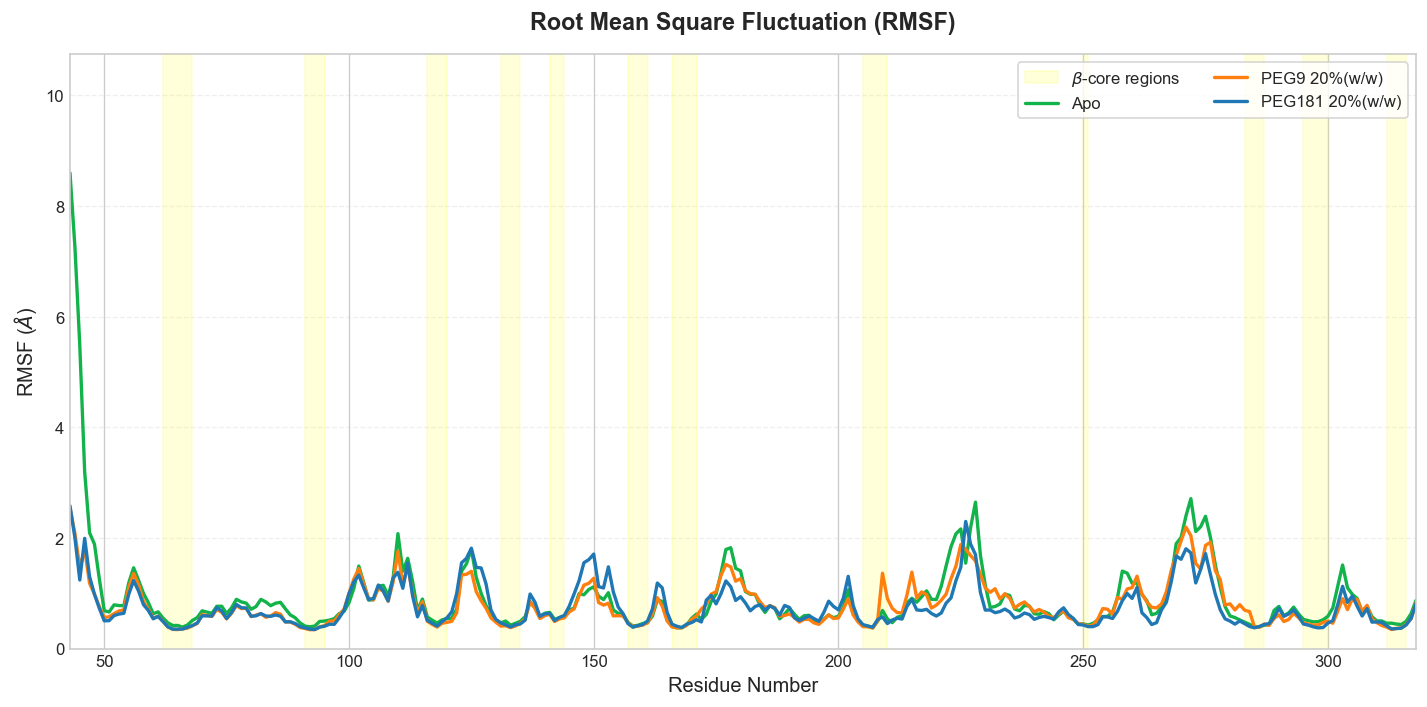

In [ ]:
all_rmsf_data = {}

for sys_info in systems:
    sys_name = sys_info['name']
    all_rmsf_data[sys_name] = run_single_rmsf(sys_info)

plot_rmsf_comparison(all_rmsf_data)

# RMSD Analysis

## Beta-Core Selection

In [ ]:
beta_core_selection = (
    "protein and name CA and ("
    "resid 62-68 or resid 91-95 or resid 116-120 or resid 131-135 or "
    "resid 141-144 or resid 157-161 or resid 166-171 or resid 205-210 or "
    "resid 250-251 or resid 283-287 or resid 295-300 or resid 312-316)"
)

In [ ]:
def run_beta_core_rmsd(system_config):
    results = {}
    for sys in system_config:

        # 載入參考結構與軌跡
        xtc_files = natural_sort(glob.glob(sys['xtc']))
        u_ref = mda.Universe(sys['pdb'])
        u_traj = mda.Universe(sys['pdb'], xtc_files)

        # 執行 RMSD 計算
        # R.run() 會自動處理對齊 (Alignment) 並計算 RMSD
        R = rms.RMSD(u_traj, u_ref,
                     select=beta_core_selection, # 用於對齊的區域
                     groupselections=[beta_core_selection] # 用於計算 RMSD 的區域
                    ).run()

        # 整理結果 (截圖 2 公式: 單位預設為 Angstrom)
        results[sys['name']] = {
            "time": R.results.rmsd[:, 1] / 1000.0, # 轉為 ns
            "rmsd": R.results.rmsd[:, 2],          # RMSD 數值 (Å)
            "color": sys['color']
        }
    return results

In [ ]:
def plot_rmsd_comparison(rmsd_data):
    plt.figure(figsize=(10, 5), dpi=120)

    for name, data in rmsd_data.items():
        # 繪製原始數據 (細線)
        plt.plot(data['time'], data['rmsd'], color=data['color'], alpha=0.3, lw=0.8)
        # 繪製移動平均線 (粗線，平滑化窗口 = 50 幀)
        ma = np.convolve(data['rmsd'], np.ones(50)/50, mode='valid')
        plt.plot(data['time'][:len(ma)], ma, color=data['color'], lw=2, label=name)


    plt.title(r"$\beta$-core $C_\alpha$ (RMSD)", fontsize=14, pad=15)
    plt.xlabel("Time (ns)", fontsize=12)
    plt.ylabel("RMSD ($\AA$)", fontsize=12)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)

    # 限制 Y 軸起點為 0
    plt.ylim(0, max([max(d['rmsd']) for d in rmsd_data.values()]) * 1.2)

    plt.tight_layout()
    plt.savefig("Beta_Core_RMSD_Comparison.png", dpi=300)
    plt.show()

In [ ]:
rmsd_data = run_beta_core_rmsd(systems)
plot_rmsd_comparison(rmsd_data)